<a href="https://colab.research.google.com/github/gkhamis04/George-Khamis/blob/main/Stock_Price_Prediction_using_Machine_Learning_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from google.colab import files
import os

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Done 🚀")

Saving kaggle.json to kaggle (1).json
Done 🚀


In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrsaurabhtanwer/tesla-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tesla-csv' dataset.
Path to dataset files: /kaggle/input/tesla-csv


In [24]:
import shutil

for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), "./")

print("done!🚀")

done!🚀


**importing libraries**

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv("/content/Tesla (1).csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [27]:
df.shape

(1692, 7)

In [28]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


**Exploratory Data Analysis**

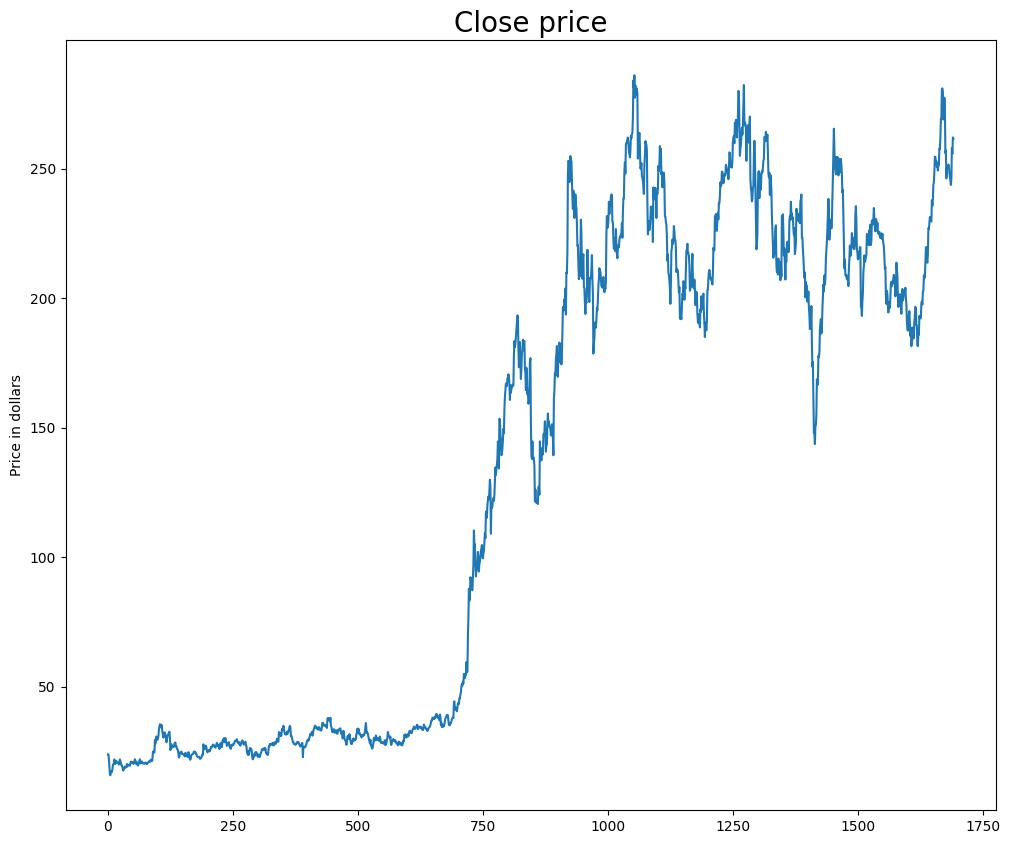

In [30]:
plt.figure(figsize=(12,10))
plt.plot(df["Close"])
plt.title("Close price", fontsize=20)
plt.ylabel("Price in dollars")
plt.show()

In [31]:
df[df['Close'] == df['Adj Close']].shape

(1692, 7)

In [32]:
df.drop("Adj Close", axis=1)

,Date,Open,High,Low,Close,Volume
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,17187100
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,8218800
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,5139800
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,6866900
...,...,...,...,...,...,...
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400


In [33]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


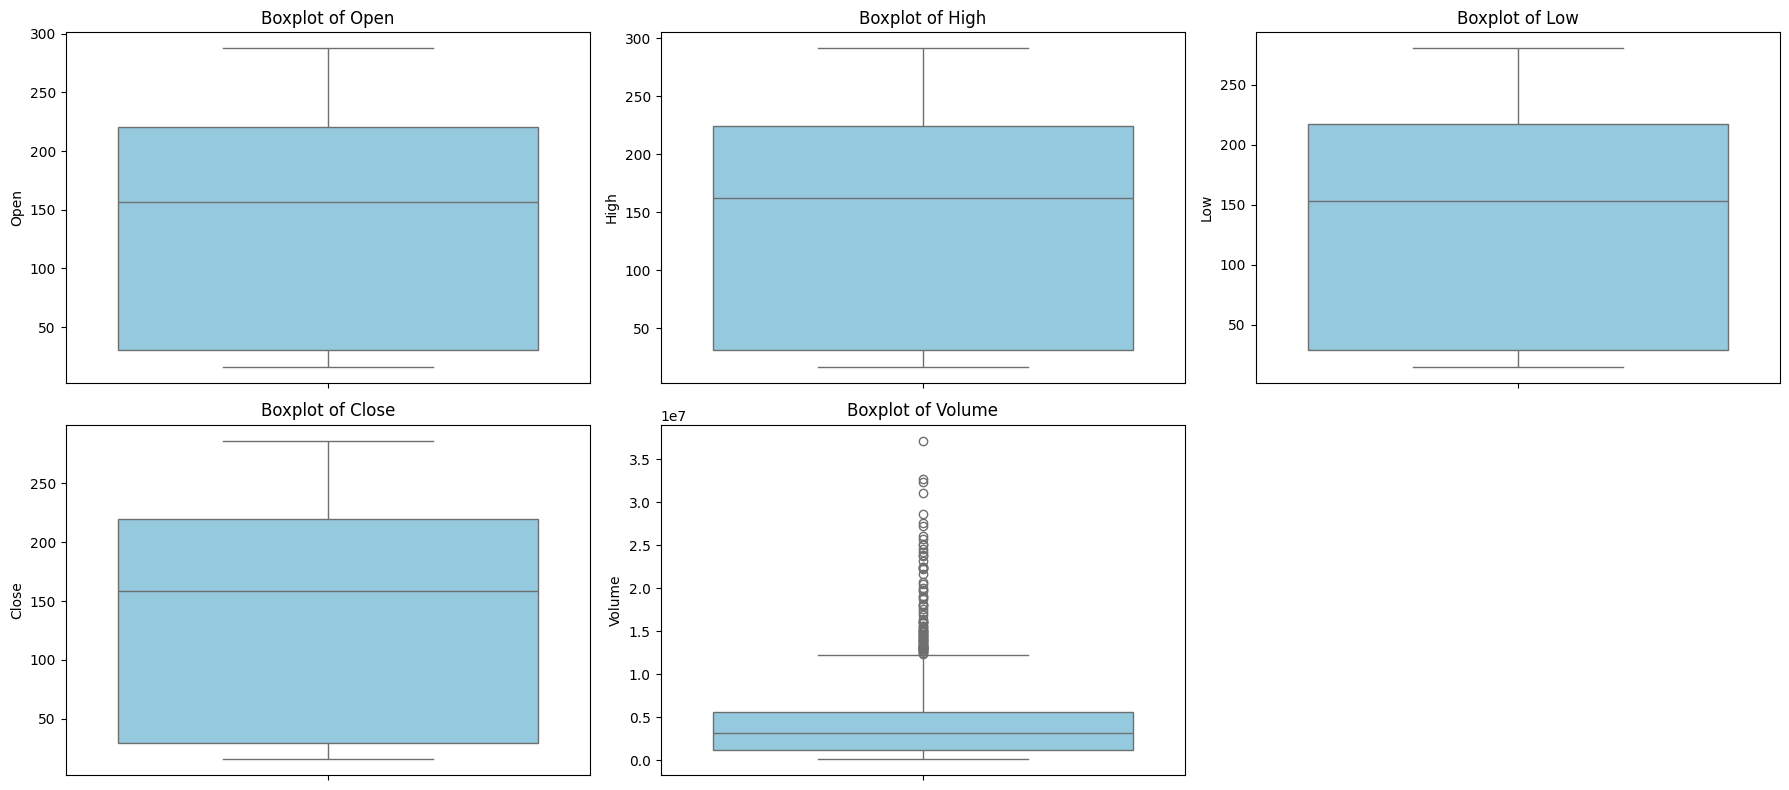

In [34]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
plt.figure(figsize=(18, 8))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

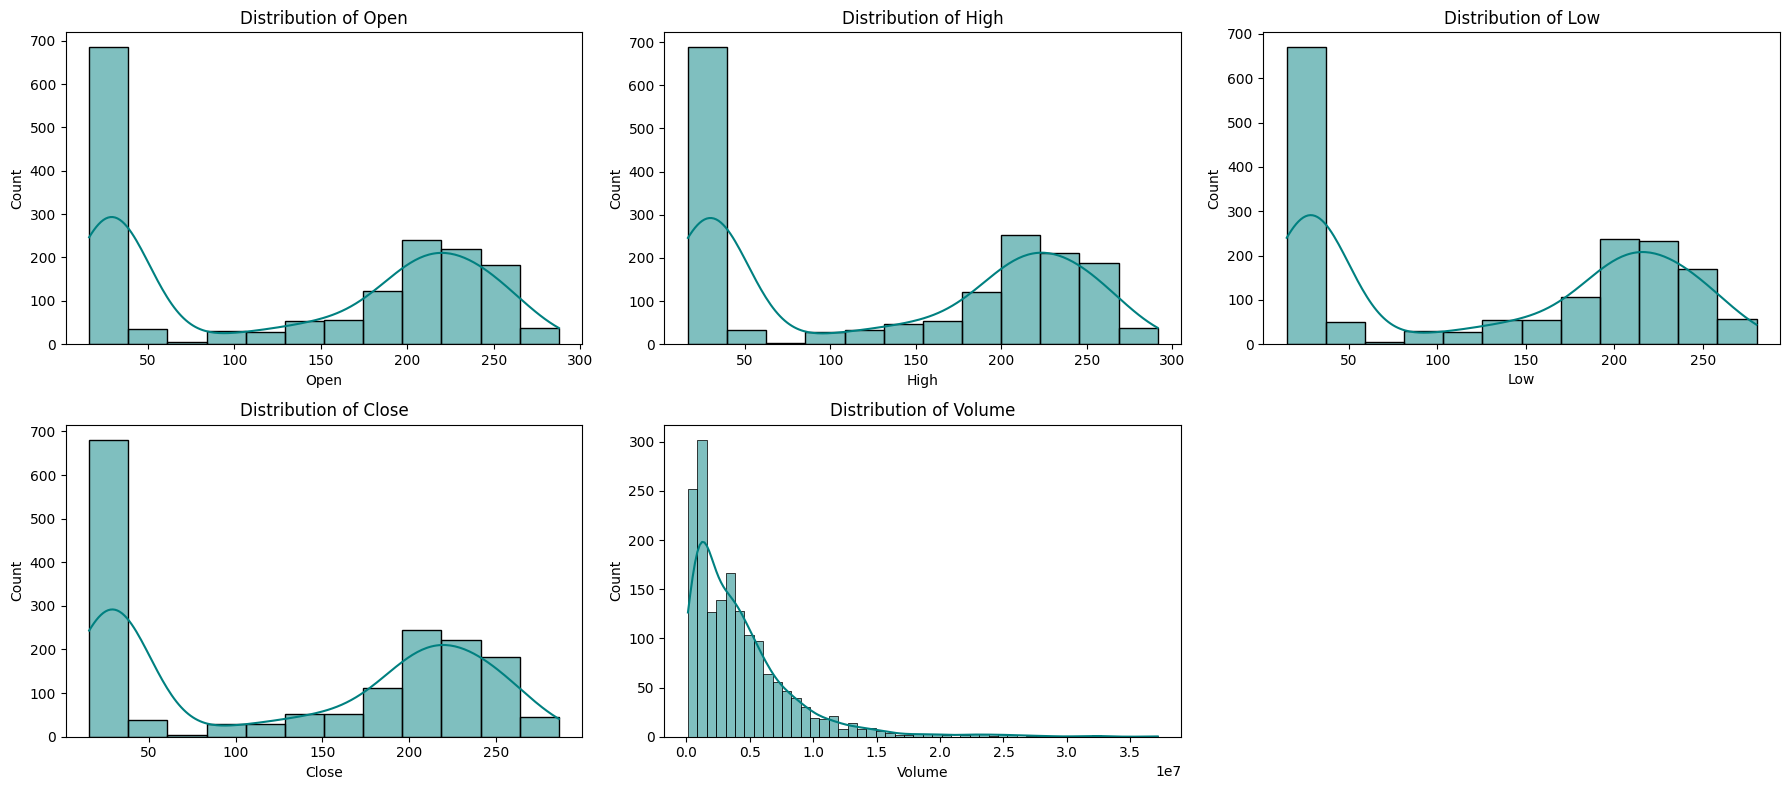

In [35]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

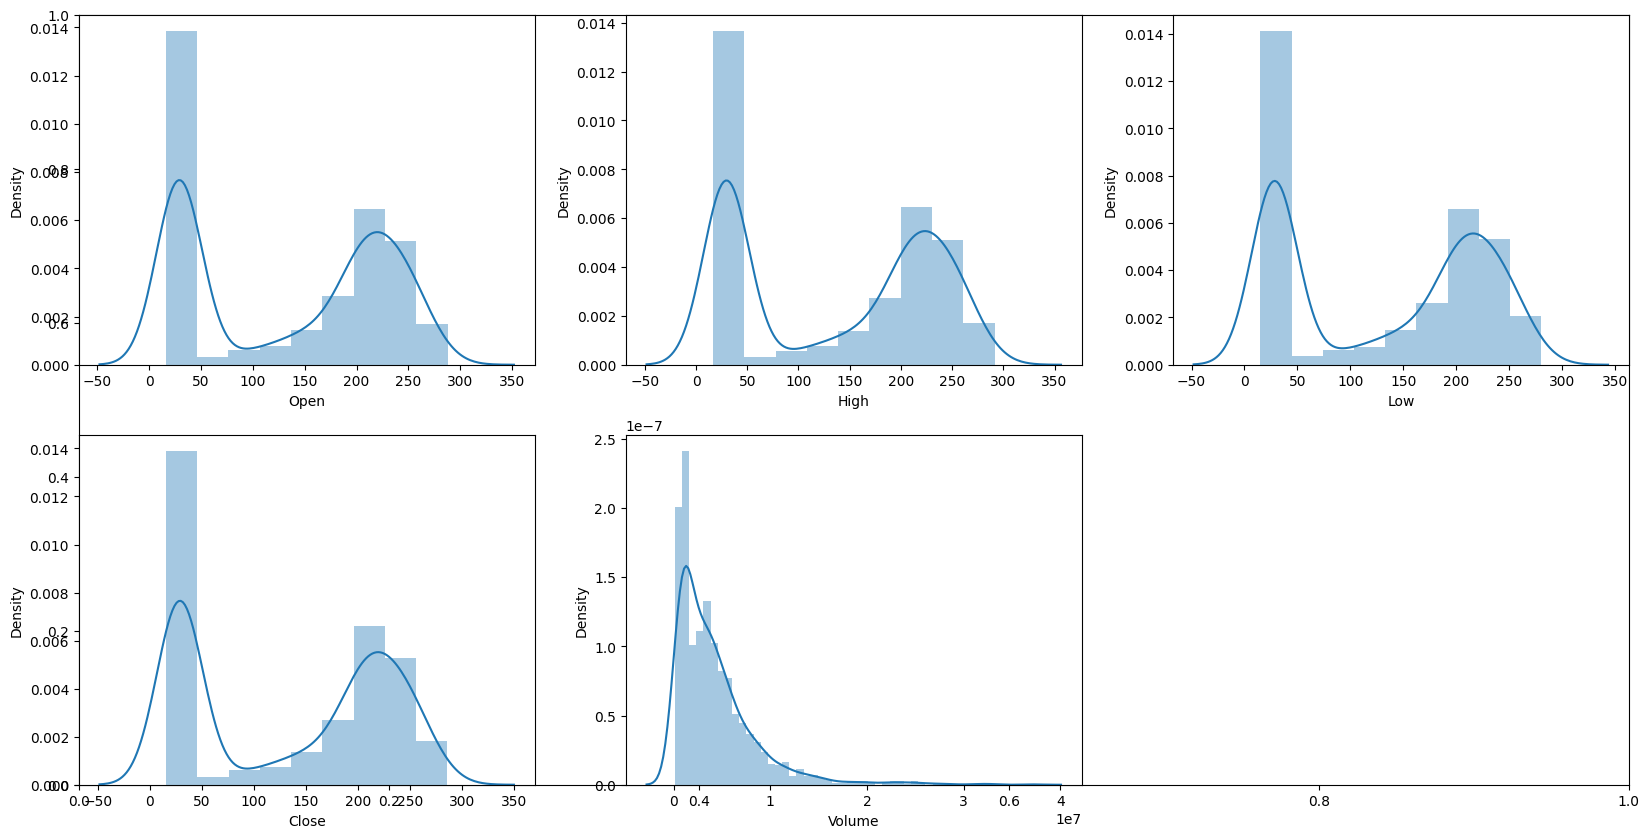

In [36]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.distplot(df[col])
plt.show()

**Feature Engineering**

In [37]:
dates=df["Date"].str.split('/', n=3,  expand=True)
df["day"] = dates[1].astype('int')
df['month'] = dates[0].astype('int')
df["year"] = dates[2].astype("int")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,day,month,year
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999,29,6,2010
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000,30,6,2010
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999,1,7,2010
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001,2,7,2010
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001,6,7,2010


In [48]:
df['month'] = pd.to_datetime(df['month'])
df['is_quarter_end'] = df['month'].dt.is_quarter_end.astype(int)

In [49]:
df["is_quartter_end"]=df['month'].dt.is_quarter_end.astype(int)

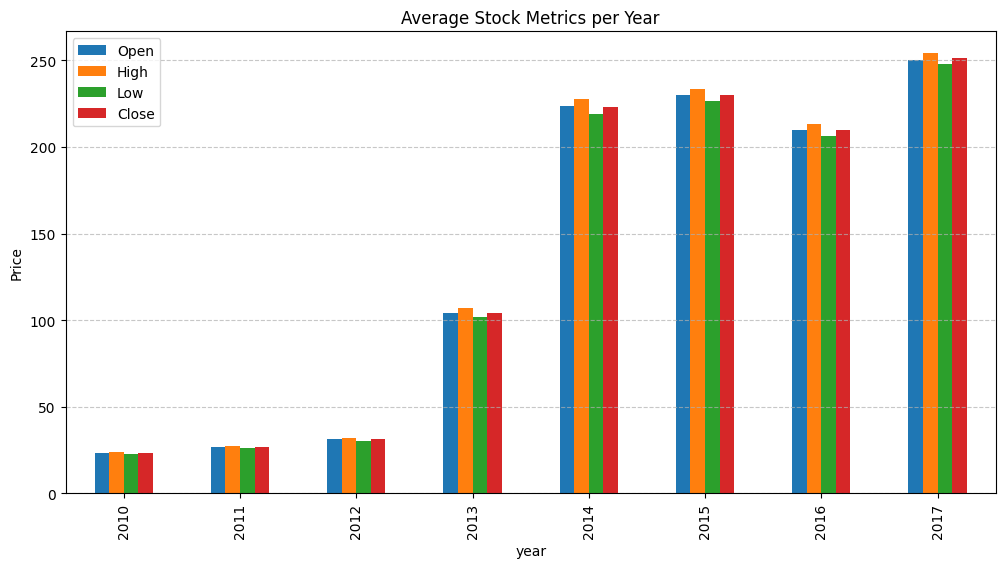

In [50]:
df.groupby('year')[['Open', 'High', 'Low', 'Close']].mean().plot.bar(figsize=(12, 6))

plt.title('Average Stock Metrics per Year')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

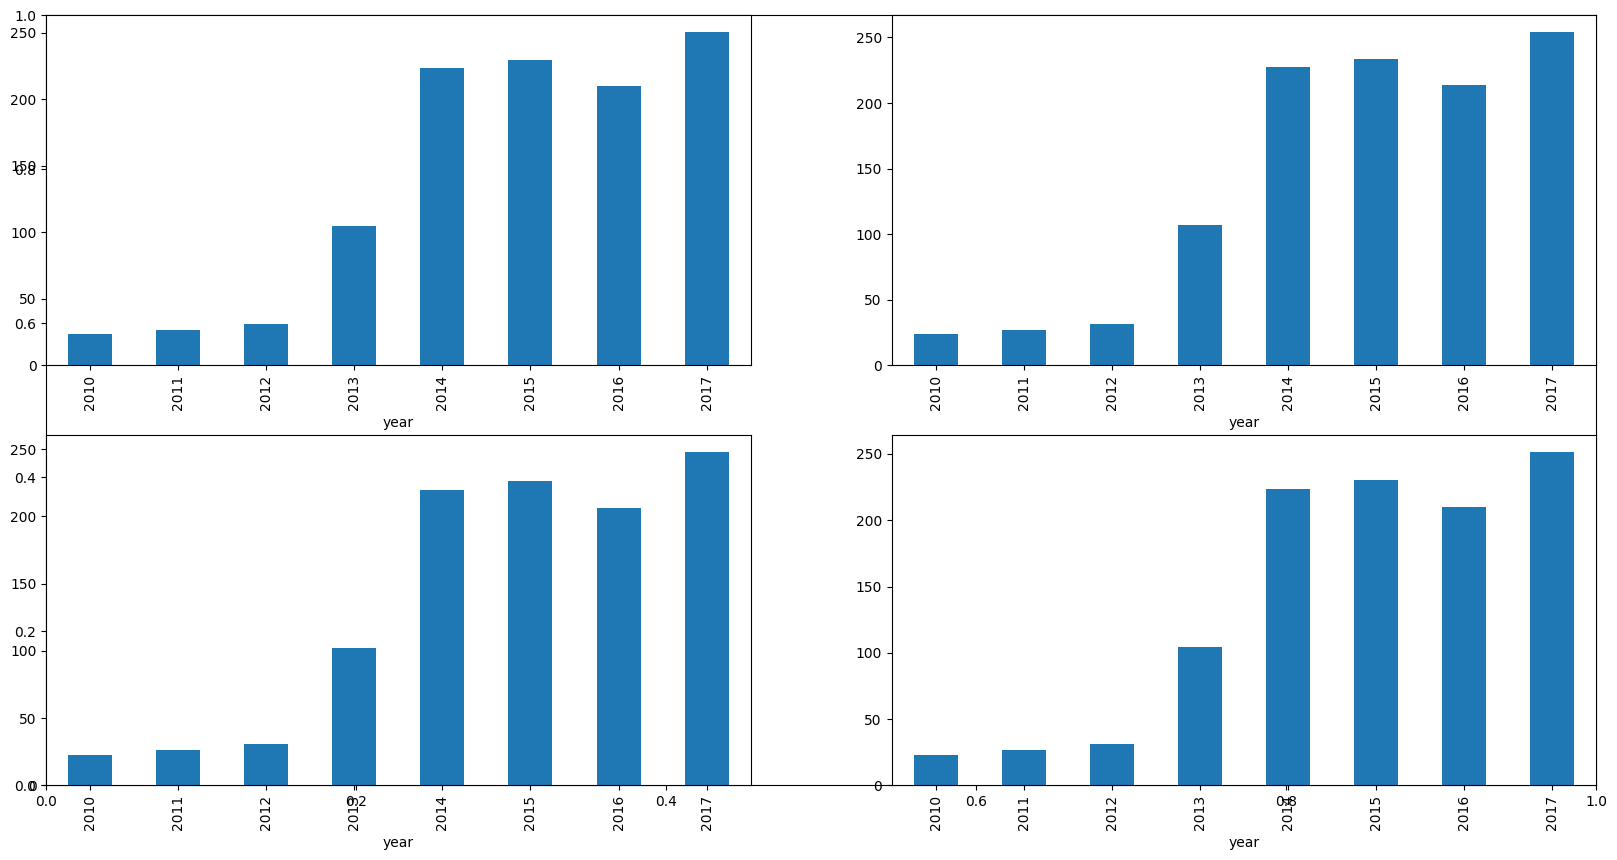

In [51]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

In [54]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean()
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,day,month,year,is_quarter_end,is_quartter_end
0,2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999,29,1970-01-01 00:00:00.000000006,2010,0,0
1,2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000,30,1970-01-01 00:00:00.000000006,2010,0,0
2,2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999,1,1970-01-01 00:00:00.000000007,2010,0,0
3,2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001,2,1970-01-01 00:00:00.000000007,2010,0,0
4,2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001,6,1970-01-01 00:00:00.000000007,2010,0,0


In [55]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean()

,Open,High,Low,Close,Volume,Adj Close,day,month,year,is_quartter_end
is_quarter_end,,,,,,,,,,
0,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658,15.676714,1970-01-01 00:00:00.000000006,2013.340426,0.0


In [57]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

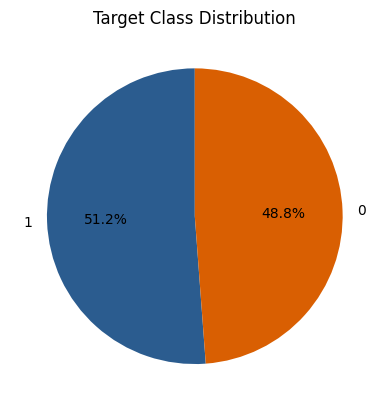

In [69]:
counts = df['target'].value_counts()

plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['#2b5c8f', '#d95f02'], startangle=90)
plt.title('Target Class Distribution')
plt.show()

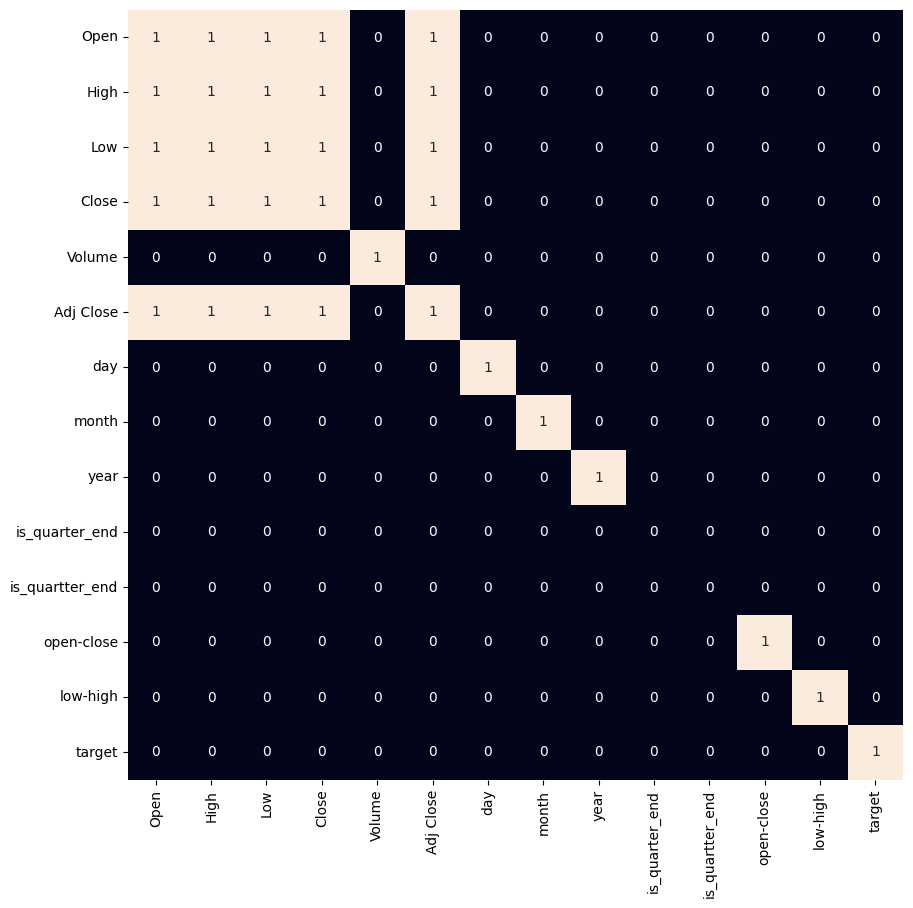

In [70]:
plt.figure(figsize=(10, 10))

sns.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()


In [73]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close,day,month,year,is_quarter_end,is_quartter_end,open-close,low-high,target
0,2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999,29,1970-01-01 00:00:00.000000006,2010,0,0,-4.889999,-7.459999,0
1,2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000,30,1970-01-01 00:00:00.000000006,2010,0,0,1.960001,-7.120001,0
2,2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999,1,1970-01-01 00:00:00.000000007,2010,0,0,3.040001,-5.650000,0
3,2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001,2,1970-01-01 00:00:00.000000007,2010,0,0,3.799999,-4.390001,0
4,2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001,6,1970-01-01 00:00:00.000000007,2010,0,0,3.889999,-4.170000,0


In [74]:
x = df[['open-close', 'low-high', 'is_quarter_end']]
y = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(x)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    x, y, test_size=0.1, random_state=2022)
print(X_train.shape, X_valid.shape)

(1522, 3) (170, 3)


In [78]:
models = [LogisticRegression(), SVC(
  kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.5142512953367876
Validation Accuracy :  0.520996640537514

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.4964101899827289
Validation Accuracy :  0.4508678611422173

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training

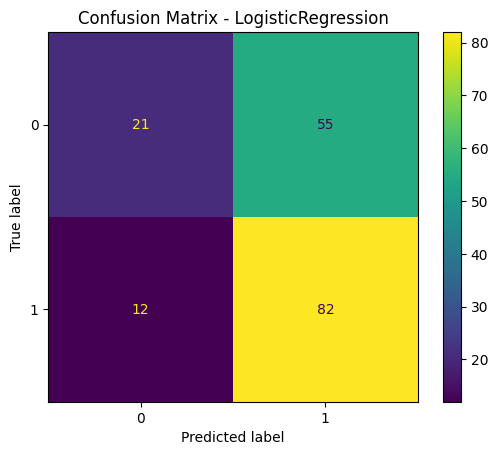

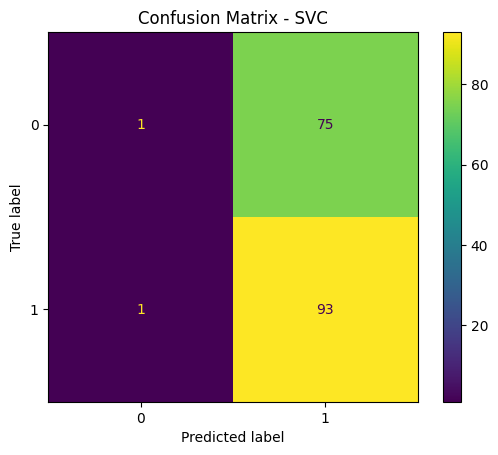

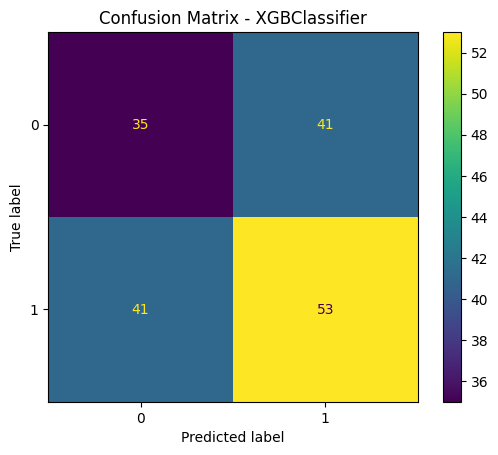

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

for model in models:
    ConfusionMatrixDisplay.from_estimator(model, X_valid, Y_valid)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()